In [1]:
import __init__

Navigated to package root


### Digit logit analysis for CIF cell parameters
- Load SLME-conditioned PKV model
- Teacher-forced forward pass on CsSnTe2 I4/mcm (tetragonal, SLME=28%)
- Heatmap grid: P(digit) at each position for cell lengths, angles, fract coords
- Shows hierarchical narrowing + symmetry constraint learning (a=b, angles=90°)

In [2]:
CKPT = "model_ckpts/mpdb_slme/PKV-opt/checkpoint-6250"
DEVICE = "cuda:0"
CONDITION_VALUE = 1.0

### Load model

In [3]:
from _utils._logit_analysis import load_model_for_logits

model, tokenizer = load_model_for_logits(CKPT, device=DEVICE)

Tokenizer validation passed: token vocabulary is consistent.


### Get CIF and reconstruct bracket format
Use the exact CsSnTe2 I4/mcm CIF the model generated (SLME=28%, tetragonal a=b)

In [24]:
import pandas as pd
from _utils._logit_analysis.cif_parser import reconstruct_bracketed_cif

df = pd.read_parquet("_artifacts/slme/slme-PKV-opt_gen.parquet")
mask = df["Generated CIF"].str.contains("'Rb8 Nb12 Br36'", na=False) & df["Generated CIF"].str.contains("C2/m", na=False)
print(f"Found {mask.sum()} matching entries in the DataFrame.")
raw_cif = df[mask].iloc[0]["Generated CIF"]
print(raw_cif)
print("\n")

bracketed_cif = reconstruct_bracketed_cif(raw_cif)
print(bracketed_cif)

Found 3 matching entries in the DataFrame.

data_Rb8Nb12Br36
loop_
 _atom_type_symbol
 _atom_type_electronegativity
 _atom_type_radius
 _atom_type_ionic_radius
 Rb 0.8200 2.3500 1.6600
 Nb 1.6000 1.4500 0.8200
 Br 2.9600 1.1500 0.8825
_symmetry_space_group_name_H-M C2/m
_cell_length_a 10.8199
_cell_length_b 17.5978
_cell_length_c 10.1844
_cell_angle_alpha 90.0000
_cell_angle_beta 115.0504
_cell_angle_gamma 90.0000
_symmetry_Int_Tables_number 12
_chemical_formula_structural Rb2(NbBr3)3
_chemical_formula_sum 'Rb8 Nb12 Br36'
_cell_volume 1742.1732
_cell_formula_units_Z 4
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
 1 'x, y, z'
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
 Rb Rb0 8 0.1069 0.3387 0.8230 1
 Nb Nb1 8 0.1316 0.0854 0.6330 1
 Nb Nb2 4 0.1207 0.0000 0.3810 1
 Br Br3 8 0.0168 0.1041 0.8123 1
 Br Br4 8 0.1981 0.3017 0.1867 1
 Br Br5 8 0.1993 0.3

### Extract logits

In [25]:
from _utils._logit_analysis import extract_digit_logits

result = extract_digit_logits(
    model, tokenizer, bracketed_cif,
    condition_value=CONDITION_VALUE,
    device=DEVICE,
    include_coords=True,
    max_coord_atoms=3,
)

for f in result["fields"]:
    print(f"{f['tag']}: {''.join(f['digit_tokens'])}")

_cell_length_a: 10.8199
_cell_length_b: 17.5978
_cell_length_c: 10.1844
_cell_angle_alpha: 90.0000
_cell_angle_beta: 115.0504
_cell_angle_gamma: 90.0000
_cell_volume: 1742.1732
_cell_formula_units_Z: 4
_atom_site_fract_x_0: 0.1069
_atom_site_fract_y_0: 0.3387
_atom_site_fract_z_0: 0.8230
_atom_site_fract_x_1: 0.1316
_atom_site_fract_y_1: 0.0854
_atom_site_fract_z_1: 0.6330
_atom_site_fract_x_2: 0.1207
_atom_site_fract_x_3: 0.0168
_atom_site_fract_x_4: 0.1981
_atom_site_fract_x_5: 0.1993
_atom_site_fract_x_6: 0.0000
_atom_site_fract_x_7: 0.1859
_atom_site_fract_x_8: 0.2318


### Plot heatmaps
Cell params only (cell lengths + angles)

Saved to plots/Rb2(NbBr3)3_gen_tags_logits.png


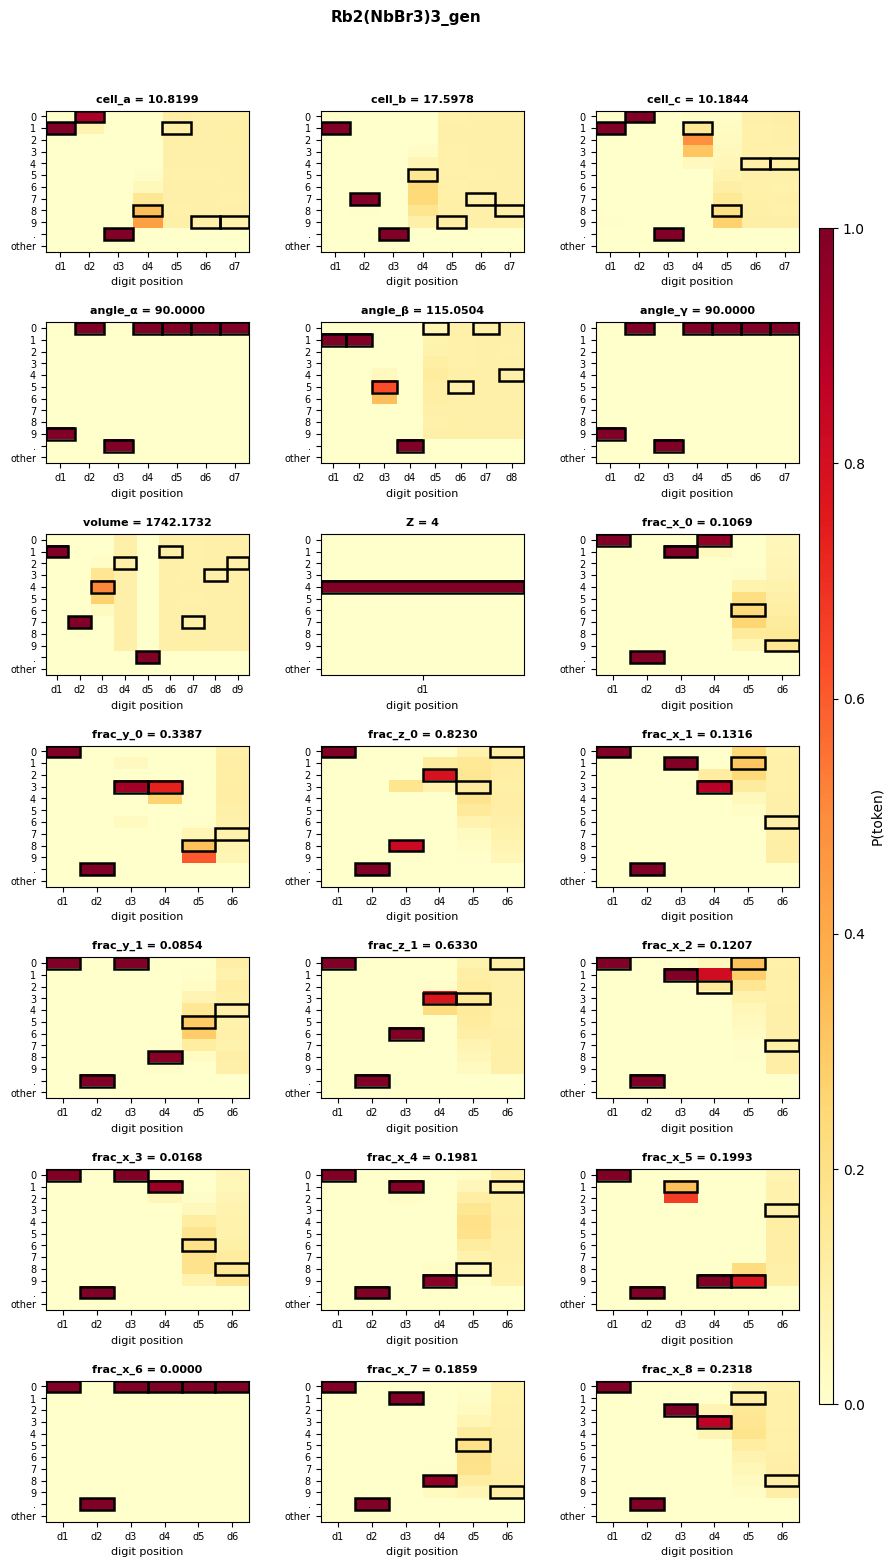

In [26]:
from _utils._logit_analysis import plot_digit_heatmap_grid
from _utils._logit_analysis.cif_parser import CELL_PARAM_TAGS

fig, axes = plot_digit_heatmap_grid(
    result["fields"],
    ncols=3,
    title="Rb2(NbBr3)3_gen",
    save_path="plots/Rb2(NbBr3)3_gen_tags_logits.png",
)